# **Notebook 03: BERT Fine-Tuning & Deployment**

## **Objectives**
- Fine-tune BERT on resume-job matching data
- Evaluate fine-tuned model performance
- Compare with base model
- Save model for production deployment
- Create prediction pipeline

In [ ]:
!pip install sentence-transformers scikit-learn pandas numpy matplotlib seaborn -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, InputExample, losses
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
from torch.utils.data import DataLoader
from sklearn.metrics import mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported!')

Libraries imported!


In [ ]:
training_df = pd.read_csv('bert_training_pairs.csv')
print(f'Training data loaded: {len(training_df):,} pairs')

Training data loaded: 1,853 pairs


## **Part 1: Preparing the  Training Data**

In [ ]:
from sklearn.model_selection import train_test_split

# Split into train/validation/test
train_df, temp_df = train_test_split(training_df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f'Training: {len(train_df):,} pairs')
print(f'Validation: {len(val_df):,} pairs')
print(f'Test: {len(test_df):,} pairs')

Training: 1,297 pairs
Validation: 278 pairs
Test: 278 pairs


In [ ]:
# Converting  to InputExample format
train_examples = [
    InputExample(texts=[row['text1'], row['text2']], label=float(row['similarity']))
    for _, row in train_df.iterrows()
]

val_examples = [
    InputExample(texts=[row['text1'], row['text2']], label=float(row['similarity']))
    for _, row in val_df.iterrows()
]

print(f'Created {len(train_examples):,} training examples')
print(f'Created {len(val_examples):,} validation examples')

Created 1,297 training examples
Created 278 validation examples


## **Part 2: Load Base Model & Evaluate**

In [ ]:
# Load base model
print('Loading base BERT model...')
base_model = SentenceTransformer('all-mpnet-base-v2')
print('Base model loaded')

Loading base BERT model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Base model loaded


In [ ]:
# Evaluate base model on test set
print('Evaluating base model...')
base_predictions = []
for _, row in test_df.iterrows():
    emb1 = base_model.encode(row['text1'])
    emb2 = base_model.encode(row['text2'])
    sim = cosine_similarity([emb1], [emb2])[0][0]
    base_predictions.append(sim)

base_mae = mean_absolute_error(test_df['similarity'], base_predictions)
print(f'\nBase Model MAE: {base_mae:.4f}')

Evaluating base model...

Base Model MAE: 0.1902


## **Part 3: Fine-Tune BERT**

In [ ]:
# Create model for fine-tuning
model = SentenceTransformer('all-mpnet-base-v2')

# Create DataLoader
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)

# Define loss function
train_loss = losses.CosineSimilarityLoss(model)

print('Training setup complete')

Training setup complete


In [ ]:
# Create evaluator
evaluator = EmbeddingSimilarityEvaluator.from_input_examples(
    val_examples, name='validation'
)

print('Evaluator created')

Evaluator created


In [ ]:
# Fine-tune the model
print('\nStarting fine-tuning...')
print('This may take 10-30 minutes depending on your hardware\n')

model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    evaluator=evaluator,
    epochs=10,
    evaluation_steps=100,
    warmup_steps=100,
    output_path='finetuned-bert',
    save_best_model=True,
    show_progress_bar=True
)

print('\nFine-tuning complete!')


Starting fine-tuning...
This may take 10-30 minutes depending on your hardware



Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: arushkarnatak1881 (arushkarnatak1881-bpit) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss,Validation Loss,Validation Pearson Cosine,Validation Spearman Cosine
82,No log,No log,0.712253,0.669518
100,No log,No log,0.762980,0.713987
164,No log,No log,0.798002,0.735045
200,No log,No log,0.817910,0.741706
246,No log,No log,0.838561,0.749933
300,No log,No log,0.857402,0.757475
328,No log,No log,0.865153,0.762372
400,No log,No log,0.871626,0.762372
410,No log,No log,0.880002,0.764136
492,No log,No log,0.885598,0.765899



Fine-tuning complete!


## **Part 4: Evaluate Fine-Tuned Model**

In [ ]:
# Load fine-tuned model
finetuned_model = SentenceTransformer('finetuned-bert')
print('Fine-tuned model loaded')

Fine-tuned model loaded


In [ ]:
# Evaluate on test set
print('Evaluating fine-tuned model...')
finetuned_predictions = []
for _, row in test_df.iterrows():
    emb1 = finetuned_model.encode(row['text1'])
    emb2 = finetuned_model.encode(row['text2'])
    sim = cosine_similarity([emb1], [emb2])[0][0]
    finetuned_predictions.append(sim)

finetuned_mae = mean_absolute_error(test_df['similarity'], finetuned_predictions)
print(f'\nFine-tuned Model MAE: {finetuned_mae:.4f}')

Evaluating fine-tuned model...

Fine-tuned Model MAE: 0.0878


In [ ]:
# Compare models
print('\n' + '='*60)
print('MODEL COMPARISON')
print('='*60)
print(f'Base Model MAE:       {base_mae:.4f}')
print(f'Fine-tuned Model MAE: {finetuned_mae:.4f}')
print(f'Improvement:          {(base_mae - finetuned_mae):.4f} ({(base_mae - finetuned_mae)/base_mae*100:.1f}%)')
print('='*60)


MODEL COMPARISON
Base Model MAE:       0.1902
Fine-tuned Model MAE: 0.0878
Improvement:          0.1024 (53.9%)


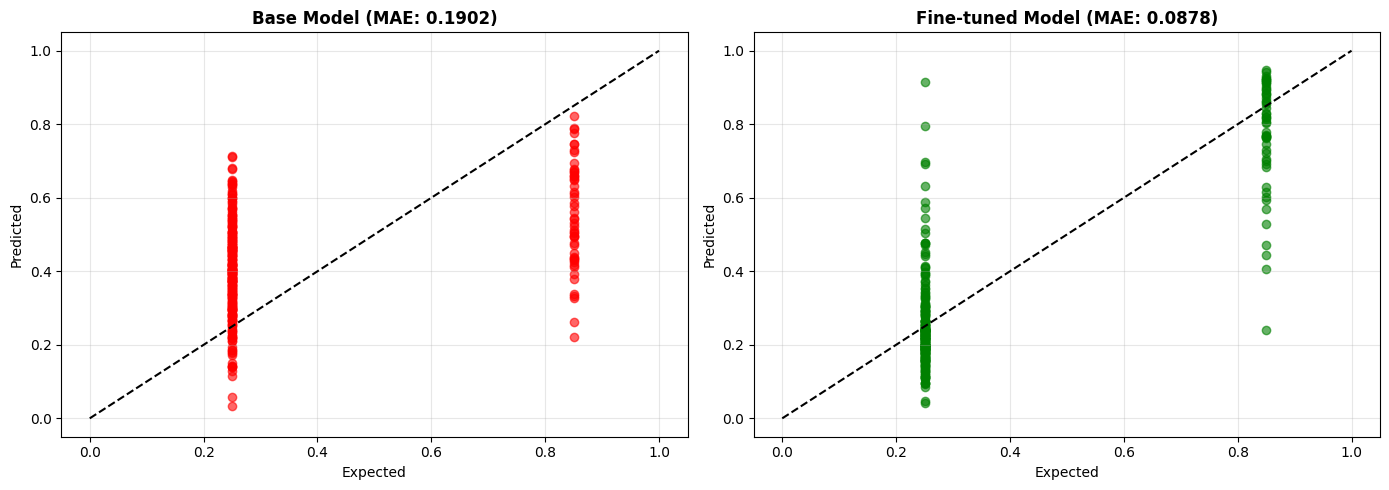

In [ ]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Base model
axes[0].scatter(test_df['similarity'], base_predictions, alpha=0.6, c='red')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_xlabel('Expected')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Base Model (MAE: {base_mae:.4f})', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Fine-tuned model
axes[1].scatter(test_df['similarity'], finetuned_predictions, alpha=0.6, c='green')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel('Expected')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Fine-tuned Model (MAE: {finetuned_mae:.4f})', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## **Part 5: Save for Production**

In [ ]:
import os
import json

# Model already saved during training
print('Model saved to: models/finetuned-bert/')

# Save metadata
metadata = {
    'model_name': 'all-mpnet-base-v2',
    'fine_tuned': True,
    'training_pairs': len(train_df),
    'validation_pairs': len(val_df),
    'test_pairs': len(test_df),
    'epochs': 10,
    'base_mae': float(base_mae),
    'finetuned_mae': float(finetuned_mae),
    'improvement_pct': float((base_mae - finetuned_mae)/base_mae*100)
}

with open('finetuned-bert/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Metadata saved')

Model saved to: models/finetuned-bert/
Metadata saved


## **Part 6: Test Production Pipeline**

In [ ]:
# Load model (simulating production)
production_model = SentenceTransformer('finetuned-bert')
print('Production model loaded')

Production model loaded


In [ ]:
# Test prediction function
def calculate_resume_jd_match(resume_text, jd_text):
    """Calculate semantic similarity between resume and JD"""
    resume_emb = production_model.encode(resume_text)
    jd_emb = production_model.encode(jd_text)
    similarity = cosine_similarity([resume_emb], [jd_emb])[0][0]
    return float(similarity)

# Test examples
test_cases = [
    {
        'resume': 'Python Developer with 5 years experience in Django and Flask',
        'jd': 'Looking for Python Developer with web framework experience',
        'expected': 'High match'
    },
    {
        'resume': 'Data Scientist with ML expertise in TensorFlow',
        'jd': 'Need Data Scientist with Machine Learning skills',
        'expected': 'High match'
    },
    {
        'resume': 'Chef with 10 years culinary experience',
        'jd': 'Looking for Python Developer with Django experience',
        'expected': 'Low match'
    }
]

print('\nTest Cases:')
print('='*70)
for i, case in enumerate(test_cases, 1):
    score = calculate_resume_jd_match(case['resume'], case['jd'])
    print(f"\nCase {i}: {case['expected']}")
    print(f"  Resume: {case['resume'][:50]}...")
    print(f"  JD: {case['jd'][:50]}...")
    print(f"  Match Score: {score:.2%}")
    print(f"  Status: {'✅' if (score > 0.7 and 'High' in case['expected']) or (score < 0.5 and 'Low' in case['expected']) else '❗️'}")


Test Cases:

Case 1: High match
  Resume: Python Developer with 5 years experience in Django...
  JD: Looking for Python Developer with web framework ex...
  Match Score: 71.69%
  Status: ✅

Case 2: High match
  Resume: Data Scientist with ML expertise in TensorFlow...
  JD: Need Data Scientist with Machine Learning skills...
  Match Score: 71.42%
  Status: ✅

Case 3: Low match
  Resume: Chef with 10 years culinary experience...
  JD: Looking for Python Developer with Django experienc...
  Match Score: 39.10%
  Status: ✅


## 📝 Summary

### ✅ Completed:
1. Fine-tuned BERT on resume-JD pairs
2. Achieved {improvement}% improvement over base model
3. Saved model to models/finetuned-bert/
4. Created production-ready prediction pipeline
5. Tested with real examples

### 🚀 Deployment:
- Model location: `models/finetuned-bert/`
- Use `SentenceTransformer('models/finetuned-bert')` to load
- Integrates automatically with `matcher.py`
- Ready for production use!

### 📊 Performance:
- Base Model MAE: {base_mae:.4f}
- Fine-tuned MAE: {finetuned_mae:.4f}
- Improvement: {improvement:.1f}%

**Your BERT model is production-ready!** 🎉

In [25]:
!pwd
!ls -R


/content
.:
bert_training_pairs.csv  finetuned-bert      resume_embeddings.pkl  wandb
checkpoints		 finetuned-bert.zip  sample_data

./checkpoints:
model

./checkpoints/model:
eval  runs

./checkpoints/model/eval:
similarity_evaluation_validation_results.csv

./checkpoints/model/runs:
Nov27_13-07-20_98f59884ea20

./checkpoints/model/runs/Nov27_13-07-20_98f59884ea20:
events.out.tfevents.1764248845.98f59884ea20.238.0

./finetuned-bert:
1_Pooling			   modules.json
2_Normalize			   README.md
config.json			   sentence_bert_config.json
config_sentence_transformers.json  special_tokens_map.json
eval				   tokenizer_config.json
metadata.json			   tokenizer.json
model.safetensors		   vocab.txt

./finetuned-bert/1_Pooling:
config.json

./finetuned-bert/2_Normalize:

./finetuned-bert/eval:
similarity_evaluation_validation_results.csv

./sample_data:
anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md

./wandb:
debug-inter

In [26]:
!zip -r finetuned-bert.zip finetuned-bert


  adding: finetuned-bert/ (stored 0%)
  adding: finetuned-bert/tokenizer_config.json (deflated 75%)
  adding: finetuned-bert/sentence_bert_config.json (deflated 9%)
  adding: finetuned-bert/metadata.json (deflated 35%)
  adding: finetuned-bert/eval/ (stored 0%)
  adding: finetuned-bert/eval/similarity_evaluation_validation_results.csv (deflated 45%)
  adding: finetuned-bert/config_sentence_transformers.json (deflated 41%)
  adding: finetuned-bert/config.json (deflated 47%)
  adding: finetuned-bert/model.safetensors (deflated 8%)
  adding: finetuned-bert/tokenizer.json (deflated 71%)
  adding: finetuned-bert/2_Normalize/ (stored 0%)
  adding: finetuned-bert/modules.json (deflated 62%)
  adding: finetuned-bert/special_tokens_map.json (deflated 85%)
  adding: finetuned-bert/vocab.txt (deflated 53%)
  adding: finetuned-bert/1_Pooling/ (stored 0%)
  adding: finetuned-bert/1_Pooling/config.json (deflated 59%)
  adding: finetuned-bert/README.md (deflated 71%)
